In [66]:
import gc
import numpy as np  
import pandas as pd  
import seaborn as sns  
import warnings 
import nltk
import string

import matplotlib.pyplot as plt  

from time import time
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

from surprise import SVD, Dataset, Reader

warnings.filterwarnings('ignore') 
tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [67]:
# Загрузка данных
books = pd.read_csv('data/books.csv')
book_tags = pd.read_csv('data/book_tags.csv')
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

# <center> **Подготовка данных**

In [68]:
# Список числовых признаков
books_numeric = [x for x in books.columns if books[x].dtype != 'object']

# Проверим диапазон значений
for col in books_numeric:
    print(f'{col}: {books[col].min()} - {books[col].max()}')
    
    
# Преобразование типов данных
# uint16: books_count
# int16: original_publication_year
# uint32: остальные целочисленные, кроме идентификаторов
# int64: isbn13
# float16: average_rating
books['books_count'] = books['books_count'].astype('uint16')
books['original_publication_year'] = books['original_publication_year'].astype('Int16')
books['isbn13'] = books['isbn13'].astype('Int64')
books['average_rating'] = books['average_rating'].astype('float16')
for col in ['books_count', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']:
    books[col] = books[col].astype('int64')


id: 1 - 10000
book_id: 1 - 33288638
best_book_id: 1 - 35534230
work_id: 87 - 56399597
books_count: 1 - 3455
isbn13: 195170342.0 - 9790007672390.0
original_publication_year: -1750.0 - 2017.0
average_rating: 2.47 - 4.82
ratings_count: 2716 - 4780653
work_ratings_count: 5510 - 4942365
work_text_reviews_count: 3 - 155254
ratings_1: 11 - 456191
ratings_2: 30 - 436802
ratings_3: 323 - 793319
ratings_4: 750 - 1481305
ratings_5: 754 - 3011543


In [69]:
# book_tags['count'] -> uint32
book_tags['count'] = book_tags['count'].astype('uint32')
# ratings['rating'] -> uint8
ratings['rating'] = ratings['rating'].astype('uint8')

In [70]:
# Из books удалим признаки со ссылками на изображения
books = books.drop(['image_url', 'small_image_url'], axis=1)

In [71]:
# Проверка на наличие полных дубликатов
print(f'Количество дубликатов в books: {books.duplicated().sum()}')
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество дубликатов в tags: {tags.duplicated().sum()}')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')

Количество дубликатов в books: 0
Количество дубликатов в book_tags: 6
Количество дубликатов в tags: 0
Количество дубликатов в ratings: 1644


In [72]:
# Дубликаты в book_tags
book_tags[book_tags.duplicated(keep=False)]

,goodreads_book_id,tag_id,count
159370,22369,25148,4
159371,22369,25148,4
265127,52629,10094,1
265128,52629,10094,1
265139,52629,2928,1
265140,52629,2928,1
265154,52629,13272,1
265155,52629,13272,1
265186,52629,13322,1
265187,52629,13322,1


In [73]:
print(f'Количество записей до удаления: {book_tags.shape[0]}')
# Удалим полные дубликаты в book_tags
book_tags.drop_duplicates(inplace=True)
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество записей после удаления: {book_tags.shape[0]}')

Количество записей до удаления: 999912
Количество дубликатов в book_tags: 0
Количество записей после удаления: 999906


In [74]:
# Дополнительно проверим дубликаты по признакам идентификаторов в ratings
print(f'Количество дубликатов в ratings по признакам book_id и user_id: {ratings.duplicated(subset=["book_id", "user_id"]).sum()}')

Количество дубликатов в ratings по признакам book_id и user_id: 2278


In [75]:
print(f'Количество записей до удаления: {ratings.shape[0]}')
# Удаление дубликатов, оставляя последнюю оценку
ratings = ratings.drop_duplicates(subset=['book_id', 'user_id'], keep='last')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')
print(f'Количество записей после удаления: {ratings.shape[0]}')

Количество записей до удаления: 981756
Количество дубликатов в ratings: 0
Количество записей после удаления: 979478


In [76]:
# Удаляем пропуски в books
books = books.dropna()

In [77]:
books.isnull().sum()

id                           0
book_id                      0
best_book_id                 0
work_id                      0
books_count                  0
isbn                         0
isbn13                       0
authors                      0
original_publication_year    0
original_title               0
title                        0
language_code                0
average_rating               0
ratings_count                0
work_ratings_count           0
work_text_reviews_count      0
ratings_1                    0
ratings_2                    0
ratings_3                    0
ratings_4                    0
ratings_5                    0
dtype: int64

# <center> **Обучение моделей**

## Train / test разделение

+ Считаем сколько оценок поставил каждый пользователь
+ Отбираем только тех, у кого оценок больше 5 (остальные идут в выборку для холодного старта)
+ У каждого пользователя случайным образом выбираем 20% записей (test)
+ Остальные записи идут в train

In [78]:
class DataSplitter:
    """Класс для разделения данных по пользователям с одинаковыми книгами."""

    def __init__(self, test_size: float = 0.2, min_user_ratings: int = 5):
        self.test_size = test_size
        self.min_user_ratings = min_user_ratings

    def split(self, ratings: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Разделяет данные: cold_start, train, test."""
        # Находим пользователей с >= min_user_ratings
        user_counts = ratings['user_id'].value_counts()
        active_users = user_counts[user_counts >= self.min_user_ratings].index
        cold_users = user_counts[user_counts < self.min_user_ratings].index

        # Разделяем на группы
        cold_ratings = ratings[ratings['user_id'].isin(cold_users)]
        active_ratings = ratings[ratings['user_id'].isin(active_users)]

        # Для активных: разделяем на train/test по пользователям
        unique_active_users = active_ratings['user_id'].unique()
        n_test_users = int(len(unique_active_users) * self.test_size)
        test_users = set(unique_active_users[:n_test_users])
        train_users = set(unique_active_users[n_test_users:])

        train_df = active_ratings[active_ratings['user_id'].isin(train_users)]
        test_df = active_ratings[active_ratings['user_id'].isin(test_users)]

        return cold_ratings, train_df, test_df

    def validate_split(self, cold_ratings: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
        """Проверяет корректность разделения."""
        cold_users = set(cold_ratings['user_id'].unique())
        train_users = set(train_df['user_id'].unique())
        test_users = set(test_df['user_id'].unique())

        # Проверка пользователей
        cold_train_overlap = cold_users.intersection(train_users)
        cold_test_overlap = cold_users.intersection(test_users)
        train_test_overlap = train_users.intersection(test_users)

        # Проверка книг (должны совпадать)
        train_books = set(train_df['book_id'].unique())
        test_books = set(test_df['book_id'].unique())
        book_overlap = train_books.intersection(test_books)

        return {
            'cold_users': len(cold_users),
            'train_users': len(train_users),
            'test_users': len(test_users),
            'cold_train_overlap': len(cold_train_overlap),
            'cold_test_overlap': len(cold_test_overlap),
            'train_test_overlap': len(train_test_overlap),
            'common_books': len(book_overlap),
            'train_books': len(train_books),
            'test_books': len(test_books)
        }

In [79]:
splitter = DataSplitter(test_size=0.2, min_user_ratings=5)
cold_ratings, train_df, test_df = splitter.split(ratings)

validation = splitter.validate_split(cold_ratings, train_df, test_df)
validation

{'cold_users': 17765,
 'train_users': 28528,
 'test_users': 7131,
 'cold_train_overlap': 0,
 'cold_test_overlap': 0,
 'train_test_overlap': 0,
 'common_books': 8574,
 'train_books': 8641,
 'test_books': 9933}

## <center> **Этап 1. Улучшенная подготовка данных**

#### Признаки пользователей: средний рейтинг, количество оценок, активность.

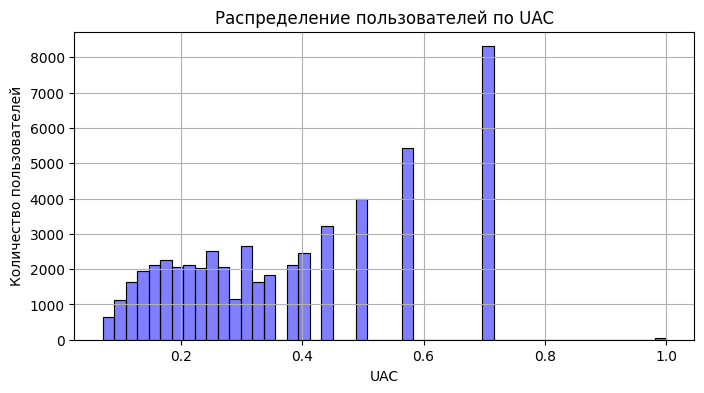

In [80]:
# Средний рейтинг и количество оценок
user_features = ratings.groupby('user_id').agg(
        user_avg_rating=('rating', 'mean'),
        user_rating_count=('book_id', 'count')
    ).reset_index()

# Активность пользователя
# Формула UAC -> 1/sqrt(d1 * d2), только для одного пользователя
user_features['user_activity_count'] = 1 / np.sqrt(user_features['user_rating_count'])

plt.figure(figsize=(8, 4))
hist = sns.histplot(user_features, x='user_activity_count', color='blue', alpha=0.5)
hist.set_title('Распределение пользователей по UAC')
hist.set_xlabel('UAC')
hist.set_ylabel('Количество пользователей')
hist.grid()

In [81]:
user_features.head()

,user_id,user_avg_rating,user_rating_count,user_activity_count
0,1,3.666667,3,0.577350
1,2,4.333333,3,0.577350
2,3,1.000000,2,0.707107
3,4,4.000000,3,0.577350
4,5,4.200000,5,0.447214


#### Признаки книг: популярность, разнообразие оценок, тематические категории.

In [82]:
# Популярность книги -> взвешенный рейтинг
books_popularity = books[['work_ratings_count', 'work_text_reviews_count']]

# Нормализуем данные, так как шкалы разные
books_popularity['pop_log_ratings'] = np.log1p(books_popularity['work_ratings_count'])
books_popularity['pop_log_reviews'] = np.log1p(books_popularity['work_text_reviews_count'])
# Смешиваем: 70% веса количеству оценок, 30% текстовым отзывам
books_popularity['popularity_index'] = (books_popularity['pop_log_ratings'] * 0.7) + (books_popularity['pop_log_reviews'] * 0.3)
books_popularity = books_popularity.drop(['work_ratings_count', 'work_text_reviews_count', 'pop_log_ratings', 'pop_log_reviews'], axis=1)
books_popularity = books_popularity.reset_index(drop=True)

In [83]:
# Разнообразие оценок
# Чем выше энтропия, тем выше разнообразие
def entrophy_calc(row):
    '''Вычисляет энтропию Шеннона по количеству
    выставленных оценок каждого типа'''
    count = row[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']]    
    total = np.sum(count)
    probs = count / total    
    probs_fl = np.array([float(x) for x in probs])    
    return -np.sum(probs_fl * np.log2(probs_fl))    

books_diversity = books.apply(entrophy_calc, axis=1)
books_diversity = books_diversity.reset_index(drop=True)

In [84]:
books_features = pd.concat([books_popularity, pd.Series(books_diversity, name='books_diversity')], axis=1)
books_features.head()

,popularity_index,books_diversity
0,14.375196,1.573085
1,14.139923,1.450875
2,14.065076,2.193653
3,13.872987,1.677672
4,13.642656,1.964913


In [85]:
np.random.seed(42)
# Тематические категории -> BERTopic
all_stop_words = set()
for lang in stopwords.fileids():
    all_stop_words.update(stopwords.words(lang))

def remove_stopwords(text):
    '''Убирает стоп-слова и пунктуацию из текста'''
    tokens = word_tokenize(text.lower())    
    tokens = [word for word in tokens if word not in all_stop_words and word not in string.punctuation]
    return ' '.join(tokens)

docs = books['original_title'].apply(remove_stopwords)
bert_model = BERTopic()
topics, probs = bert_model.fit_transform(docs)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 784.73it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [86]:
topics_info = bert_model.get_topic_info()
display(topics_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2095,-1_dark_mr_private_story,"[dark, mr, private, story, shannara, things, k...","[red prophet tales alvin maker 2, fury dark re..."
1,0,423,0_amor_storia_histoire_geschichte,"[amor, storia, histoire, geschichte, cien, spl...","[cien sonetos amor, män hatar kvinnor flickan ..."
2,1,135,1_god_jesus_gods_preacher,"[god, jesus, gods, preacher, faith, antichrist...","[conversations god uncommon dialogue book 2, g..."
3,2,123,2_desu_nto_ichikyhachiyon_bleach,"[desu, nto, ichikyhachiyon, bleach, 1q84, dans...","[デスノート 2 desu nōto gōryū 合流, デスノート 3 desu nōto..."
4,3,111,3_scarlet_alice_elizabeth_mary,"[scarlet, alice, elizabeth, mary, miss, duches...","[alice, scarlet, scarlet]"
5,4,77,4_house_home_room_welcome,"[house, home, room, welcome, long, kitchen, im...","[house, house, house]"
6,5,76,5_death_grief_immortal_observed,"[death, grief, immortal, observed, unnatural, ...","[born death death 23, immortal death, death]"
7,6,73,6_art_happiness_success_gogh,"[art, happiness, success, gogh, habits, vincen...","[letters vincent gogh, art happiness handbook ..."
8,7,65,7_girl_girls_samantha_pretty,"[girl, girls, samantha, pretty, dangerous, acc...","[girl, girl, girl]"
9,8,58,8_book_hitchhiker_fahrenheit_451,"[book, hitchhiker, fahrenheit, 451, reader, 39...","[book life, book, book]"


In [87]:
print('books shape', books.shape)
print('len topics', len(topics))

books shape (7860, 21)
len topics 7860


In [88]:
# формируем признаки тем
book_topic = pd.concat([
                        books['book_id'].reset_index(drop=True),
                        pd.Series(topics, name='topic_id')
                                                        ], axis=1)
def get_embedding(topic_id):    
    return bert_model.topic_embeddings_[topic_id]

book_topic['topic_embedding'] = book_topic['topic_id'].apply(get_embedding)

In [89]:
books_features = pd.concat([books_features, book_topic], axis=1)
books_features.head()

,popularity_index,books_diversity,book_id,topic_id,topic_embedding
0,14.375196,1.573085,2767052,191,"[-0.030452967, 0.049170744, -0.024672115, -0.0..."
1,14.139923,1.450875,3,54,"[-0.071755454, 0.0058148187, -0.02467206, 0.04..."
2,14.065076,2.193653,41865,149,"[-0.026308052, 0.041757558, 0.04393011, -0.003..."
3,13.872987,1.677672,2657,-1,"[-0.020745538, -0.03429796, -0.044015206, 0.03..."
4,13.642656,1.964913,4671,-1,"[-0.020745538, -0.03429796, -0.044015206, 0.03..."


#### Признаки взаимодействий: схожесть с историей пользователя.

In [115]:
tqdm.pandas(desc='Группировка тегов')
gc.collect()

# Объединяем теги с их названиями
book_tags_joined = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id')
# Группируем теги в строки (без раздувания, для экономии памяти)
book_descriptions = (
    book_tags_joined
    .groupby('goodreads_book_id')['tag_name']
    .progress_apply(lambda x: ' '.join(x.astype(str)))
    .reset_index(name='tag_str')
)
# Очистка памяти
del book_tags_joined 
gc.collect()

# Векторизация книг (Content Space)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', dtype=np.float32)
item_vectors = tfidf.fit_transform(book_descriptions['tag_str'])
item_vectors = normalize(item_vectors)

# Маппинг: book_id в базе -> индекс строки в матрице item_vectors
book_id_to_idx = {id: i for i, id in enumerate(book_descriptions['goodreads_book_id'])}

# Создание профилей пользователей (User Profiles)
top_ratings = ratings[ratings['rating'] >= 4].copy()
# Оставляем только те книги, для которых у нас есть текстовое описание (теги)
top_ratings = top_ratings[top_ratings['book_id'].isin(book_id_to_idx)]

# фиксируем размерности
num_books = item_vectors.shape[0]           
num_users = ratings['user_id'].max() + 1      
rows = top_ratings['user_id'].values
cols = top_ratings['book_id'].map(book_id_to_idx).values
data = top_ratings['rating'].values

# Создаем разреженную матрицу User-Item 
user_item_matrix = csr_matrix((data, (rows, cols)), shape=(num_users, num_books))
# Считаем профили: перемножаем взаимодействия на признаки книг
user_profiles = user_item_matrix.dot(item_vectors)
user_profiles = normalize(user_profiles) 

# Функция для  расчета схожести 
def get_similarity_batch(user_ids, book_ids, user_profiles, item_vectors, book_id_to_idx):    
    # Получаем индексы книг (те, что не найдены, помечаем как -1)
    b_indices = np.array([book_id_to_idx.get(bid, -1) for bid in book_ids])    
    # Маска для существующих книг (чтобы избежать ошибок индексации)
    valid_mask = b_indices != -1    
    # Подготавливаем массив для результатов
    sims = np.zeros(len(user_ids))    
    if valid_mask.any():
        # Извлекаем векторы пользователей и книг только для валидных индексов
        u_vecs = user_profiles[user_ids[valid_mask]]
        b_vecs = item_vectors[b_indices[valid_mask]]        
        # Скалярное произведение нормализованных векторов (Cosine Similarity)        
        batch_sims = np.array(u_vecs.multiply(b_vecs).sum(axis=1)).flatten()
        sims[valid_mask] = batch_sims
        
    return sims

# Финальный расчет признака для всей таблицы ratings
ratings['history_similarity'] = get_similarity_batch(
    user_ids=ratings['user_id'].values,     
    book_ids=ratings['book_id'].values,    
    user_profiles=user_profiles,           
    item_vectors=item_vectors,            
    book_id_to_idx=book_id_to_idx          
)

gc.collect()

Группировка тегов: 100%|██████████| 10000/10000 [00:00<00:00, 16602.03it/s]


0

### Popularity Recommender

In [116]:
class PopularityRecommender:
    '''Модель рекоммендаций книг по популярности'''
    def __init__(self, threshold: float = 4.0):        
        self.threshold = threshold
        self.popular_books = None 
        
    def fit(self, books: pd.DataFrame):
        '''Отбирает книги с рейтингом выше порога'''
        self.popular_books = books[books['average_rating'] >= self.threshold].reset_index(drop=True)
        
    def recommend(self, user_id: int = None, k: int = 5,) -> pd.DataFrame:
        recs = self.popular_books[['book_id', 'authors', 'original_title', 'average_rating']].copy()
        sample_size = min(k, len(recs))
        recommendations = recs.sample(n=sample_size).reset_index(drop=True)
        return recommendations    

### Content Recommender

In [117]:
class ContentRecommender:
    '''Контентная модель рекоммендаций,
    основанная на косинусной близости'''
    def __init__(self):        
        self.tfidf_matrix = None
        self.vectorizer = None 
        self.books_with_features = None 
        
    def fit(self, books: pd.DataFrame, book_tags: pd.DataFrame, tags: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель: TfIdf векторизация и вычисление косинусной близости'''
        # Объединяем теги
        book_tags_names = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id', how='left')
        book_to_tags = book_tags_names.groupby('goodreads_book_id')['tag_name'].apply(
            lambda x: ' '.join(x.astype(str))
        ).reset_index(name='tag_str')
        
        # Объединяем с книгами
        self.books_with_features = books[['book_id', 'authors', 'original_title']].merge(
            book_to_tags, left_on='book_id', right_on='goodreads_book_id', how='left'
        ).fillna('').drop('goodreads_book_id', axis=1)
        
        # Добавляем новые признаки
        self.books_with_features = self.books_with_features.merge(
            book_features[['book_id', 'topic_embedding', 'popularity_index', 'books_diversity', 'topic_id']],
            on='book_id', how='left'
        ).fillna(0)

          #  Создаем текстовый профиль
        self.books_with_features['profile'] = (
            self.books_with_features['original_title'] + ' ' +
            self.books_with_features['tag_str']
        )
        
        # Векторизация
        self.vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        self.tfidf_matrix = self.vectorizer.fit_transform(self.books_with_features['profile'])
        
    def recommend(self, user_id: int, books_df: pd.DataFrame,
                  ratings_df: pd.DataFrame, book_tags: pd.DataFrame,
                  tags: pd.DataFrame, books_features_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
        # Проверяем, обучена ли модель
        if self.books_with_features is None:
            print("ContentRecommender not fitted yet.")
            return pd.DataFrame(columns=['book_id', 'authors', 'original_title'])

        # Берем прочитанные пользователем книги
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        user_read_books = user_ratings['book_id'].unique().tolist()
        if not user_read_books:
            # Если нет прочитанных книг, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)

        # Выбираем случайно одну
        selected_book_id = np.random.choice(user_read_books)
        # Находим индекс книги
        idx_series = self.books_with_features[self.books_with_features['book_id'] == selected_book_id].index
        if len(idx_series) == 0:
            # Если книга не найдена, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)
        idx = idx_series[0] # Получаем первый индекс

        # Считаем косинусное сходство
        # Обеспечиваем, что индекс валиден для tfidf_matrix
        if idx >= self.tfidf_matrix.shape[0]:
            print(f"Warning: Index {idx} out of bounds for tfidf_matrix with shape {self.tfidf_matrix.shape}. Returning popular books.")
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)

        # Извлекаем строку и вычисляем сходства
        single_row = self.tfidf_matrix[idx] # Это будет csr_matrix (1, n_features)
        sim_scores_raw = cosine_similarity(single_row, self.tfidf_matrix) # Результат: (1, n_books)

        # Конвертируем в плотный ndarray и затем во flat 1D array
        # .A1 эквивалентно np.asarray(X).ravel() для матриц/массивов
        sim_scores_dense = np.asarray(sim_scores_raw).flatten()

        # Заменяем возможные NaN/inf на числа (хотя cosine_similarity обычно не дает NaN/inf)
        sim_scores_clean = np.nan_to_num(sim_scores_dense, nan=0.0, posinf=1.0, neginf=-1.0)

        # Исключаем саму книгу (idx) - устанавливаем её схожесть в -1 или 0, чтобы точно не выбрать
        sim_scores_clean[idx] = -2.0 # Устанавливаем заведомо низкое значение

        # Проверяем, что массив чисел
        if not np.issubdtype(sim_scores_clean.dtype, np.number):
             print("Warning: sim_scores_clean contains non-numeric data. Returning empty DataFrame.")
             return pd.DataFrame(columns=['book_id', 'authors', 'original_title'])

        # Сортируем индексы по убыванию значений схожести
        # np.argsort возвращает индексы, которые бы отсортировали массив
        # [::-1] переворачивает результат, чтобы получить сортировку по убыванию
        # [:k] берет первые k индексов (самые похожие)
        top_indices = np.argsort(sim_scores_clean)[::-1][:k]

        # Возвращаем датафрейм с топ-K книгами
        # iloc выбирает строки по индексу (целочисленному), который находится в top_indices
        return self.books_with_features.iloc[top_indices][['book_id', 'authors', 'original_title']]

### Item-Based Collaborative Filtering

In [118]:
class CFRecommender:
    '''Реализует Item-Based коллаборативную фильтрацию'''

    def __init__(self, use_implicit: bool = False):
        self.use_implicit = use_implicit # Использовать ли неявный фидбек       
        self.user_book_matrix = None
        self.book_similarity_matrix = None
        self.user_features = None
        self.book_features = None
        self.history_similarity = None
        self.books = None

    def fit(self, ratings: pd.DataFrame, books: pd.DataFrame, user_features: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель. Строит матрицы.'''
        self.books = books
        # Подготовка ratings
        if self.use_implicit:
            ratings = ratings.copy()
            ratings['rating'] = (ratings['rating'] >= 4).astype(int)
    
        # Уникальные id
        unique_users = ratings['user_id'].unique()
        unique_books = ratings['book_id'].unique()
    
        # Маппинг в индексы
        user_to_idx = {u: i for i, u in enumerate(unique_users)}
        book_to_idx = {b: i for i, b in enumerate(unique_books)}
    
        # Создание разреженной матрицы (Book x User)
        rows = ratings['book_id'].map(book_to_idx)
        cols = ratings['user_id'].map(user_to_idx)
        data = ratings['rating']
    
        user_book_sparse = csr_matrix((data, (rows, cols)), shape=(len(unique_books), len(unique_users)))
    
        # Сохраняем как обычную матрицу
        self.user_book_matrix = pd.DataFrame(
            user_book_sparse.toarray(),
            index=unique_books,
            columns=unique_users
        )
    
        # Матрица схожести книг (косинусная близость)
        book_similarity = cosine_similarity(user_book_sparse)
        self.book_similarity_matrix = pd.DataFrame(
            book_similarity,
            index=unique_books,
            columns=unique_books
        )
    
        # Сохраняем признаки
        self.user_features = user_features.set_index('user_id')[['user_avg_rating', 'user_rating_count', 'user_activity_count']]
        self.book_features = book_features.set_index('book_id')[['popularity_index', 'books_diversity', 'topic_embedding']]
        self.history_similarity = ratings.set_index(['user_id', 'book_id'])['history_similarity']

    def predict_rating(self, user_id: int, book_id: int) -> float:
        '''Предсказывает оценку'''
        if book_id not in self.book_similarity_matrix.index or user_id not in self.user_book_matrix.columns:
            return 0.0

        # Схожесть с book_id
        similarities = self.book_similarity_matrix.loc[book_id]
        user_ratings = self.user_book_matrix[user_id]

        # Оставляем только оцененные книги
        rated_books = user_ratings[user_ratings > 0].index
        # Берем только k самых похожих книг из оцененных
        similar_books = similarities[rated_books].sort_values(ascending=False)

        # Взвешенное усреднение
        numerator = 0.0
        denominator = 0.0
        for b, sim in similar_books.items():
            numerator += sim * user_ratings[b]
            denominator += abs(sim)

        return numerator / denominator if denominator > 0 else 0.0

    def recommend(self, user_id: int, k: int = 5) -> pd.DataFrame:
        '''Возвращает топ-K рекомендованных книг для пользователя в виде DataFrame'''      
        
        if user_id not in self.user_book_matrix.columns:
            # Если пользователя нет, возвращаем популярные книги
            if hasattr(self, 'books') and self.books is not None:
                popular_books = self.books.nlargest(k, 'average_rating')
                return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)
            else:
                return pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
        
        user_ratings = self.user_book_matrix[user_id] # Книги, которые пользователь оценил
        unrated_books = user_ratings[user_ratings == 0].index # Книги, которые пользователь не оценил
        
        if len(unrated_books) == 0:
            print('Нет непрочитанных книг для пользователя')           
            if hasattr(self, 'books') and self.books is not None:
                popular_books = self.books.nlargest(k, 'average_rating')
                return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)
            else:
                return pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
        
        # Предсказание оценок для непрочитанных книг
        predictions = [] 
        for book_id in unrated_books:
            pred = self.predict_rating(user_id, book_id) 
            predictions.append((book_id, pred))
            
        # Сортируем оценки по убыванию
        predictions.sort(key=lambda x: x[1], reverse=True)
        
        # Фильтруем, чтобы брать только книги, которые есть в books_df
        if hasattr(self, 'books') and self.books is not None:
            all_available_books = set(self.books['book_id'].values)
            top_k_filtered = [(book_id, score) for book_id, score in predictions if book_id in all_available_books]
        else:
            top_k_filtered = predictions
        
        # Выбираем топ-k книг
        top_k_books = [x[0] for x in top_k_filtered[:k]]
       
        # Фильруем датафрейм с информацией о книгах по id
        if hasattr(self, 'books') and self.books is not None and top_k_books:
            recommended = self.books[self.books['book_id'].isin(top_k_books)]
            # Сортируем по порядку 
            recommended = recommended.set_index('book_id').loc[top_k_books].reset_index()
        else:
            # Если нет книг, возвращаем пустой датафрейм
            recommended = pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
            
        return recommended[['book_id', 'authors', 'original_title', 'average_rating']]

### SVD Recommender

In [119]:
class SVDRecommender:
    '''Реализует SVD рекомендации'''
    def __init__(self, n_factors: int = 100, n_epochs: int = 100, lr_all: float = 0.007, random_state: int = 42):        
        self.SVD = SVD  # Сохраняем класс для использования
        self.model = SVD(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr_all, random_state=random_state)
        self.reader = Reader(rating_scale=(1, 5))
        self.trainset = None
        self.user_features = None
        self.book_features = None
        self.history_similarity = None        

    def fit(self, ratings: pd.DataFrame, user_features: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель с признаками'''        
        # Сохраняем признаки
        self.user_features = user_features.set_index('user_id')[['user_avg_rating', 'user_rating_count', 'user_activity_count']]
        self.book_features = book_features.set_index('book_id')[['popularity_index', 'books_diversity', 'topic_embedding']]
        self.history_similarity = ratings.set_index(['user_id', 'book_id'])['history_similarity']

        # Подготовка данных для Surprise
        data = Dataset.load_from_df(ratings[['user_id', 'book_id', 'rating']], self.reader)
        self.trainset = data.build_full_trainset()
        self.model.fit(self.trainset)

    def recommend(self, user_id: int, books_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
        '''Рекомендует книги'''        
        # Проверяем, известен ли пользователь
        try:
            inner_id = self.trainset.to_inner_uid(user_id)
        except ValueError:
            # Пользователь неизвестен, возвращаем популярные книги
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)

        # Все книги, доступные в books_df
        all_books = set(books_df['book_id'].values)
        # Книги, которые пользователь уже оценил
        user_items = set([self.trainset.to_raw_iid(i) for i, _ in self.trainset.ur[inner_id]])
        # Книги, которые пользователь не оценил
        unrated_books = list(all_books - user_items)

        # Предсказания
        predictions = [
            (book_id, self.model.predict(user_id, book_id).est)
            for book_id in unrated_books[:min(1000, len(unrated_books))]  # ограничиваем для производительности
        ]
        predictions.sort(key=lambda x: x[1], reverse=True)

        # Топ-K
        top_k_books = [x[0] for x in predictions[:k]]
        if not top_k_books:
            # Если нет рекомендаций, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)

        recommendations = books_df[books_df['book_id'].isin(top_k_books)]
        recommendations = recommendations.set_index('book_id').loc[top_k_books].reset_index()

        return recommendations[['book_id', 'authors', 'original_title', 'average_rating']]

### Hybrid Recommender

In [120]:
class HybridRecommender:
    '''Гибридная система рекомендаций'''
    def __init__(self, popularity_model, content_model, cf_model, svd_model):
        self.popularity_model = popularity_model
        self.content_model = content_model
        self.cf_model = cf_model
        self.svd_model = svd_model

    def recommend(self, user_id: int, books_df: pd.DataFrame, ratings_df: pd.DataFrame, 
                  book_tags: pd.DataFrame, tags: pd.DataFrame, books_features: pd.DataFrame,
                  user_features: pd.DataFrame, k: int = 5):
        '''Генерирует рекомендации для пользователя'''
        # Считаем, сколько книг оценил пользователь 
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        n_ratings = user_ratings['book_id'].nunique()

        # Если мало оценок — используем популярность
        if n_ratings < 5:
            self.popularity_model.fit(books_df)
            print(f'Popularity Model for user {user_id} (ratings: {n_ratings})')
            return self.popularity_model.recommend(user_id, k=k)
        
        # Если оценок от 5 до 100 - контентная модель
        # if 5 <= n_ratings < 100:
        #     # Берем прочитанные пользователем книги
        #     user_read_books = user_ratings['book_id'].unique().tolist()
            
        #     if not user_read_books:
        #         self.popularity_model.fit(books_df)
        #         return self.popularity_model.recommend(user_id, k=k)
                
        #     # Выбираем случайно одну            
        #     selected_book_id = np.random.choice(user_read_books)
            
        #     # Обучаем контентную модель (если она еще не обучена)
        #     if not hasattr(self.content_model, 'books_with_features') or self.content_model.books_with_features is None:
        #         self.content_model.fit(books_df, book_tags, tags, books_features)  
            
        #     print(f'Content Model for user {user_id} (ratings: {n_ratings})')
        #     # Используем выбранную книгу для получения похожих
        #     try:
        #         similar_recs = self.content_model.recommend(user_id, books, ratings, book_tags, tags, books_features, k=5)
        #         if similar_recs is not None and not similar_recs.empty:
        #             return similar_recs[['book_id', 'authors', 'original_title']].head(k)
        #         else:
        #             # Если не удалось найти похожие, возвращаем популярные
        #             self.popularity_model.fit(books_df)
        #             return self.popularity_model.recommend(user_id, k=k)
        #     except Exception as e:
        #         print(f"Error in content model: {e}")
        #         self.popularity_model.fit(books_df)
        #         return self.popularity_model.recommend(user_id, k=k)
        else:
        # Если оценок >= 5 - используем коллаборативные фильтры
            try:
                # Обучаем модели
                self.cf_model.fit(ratings_df, books_df, user_features, books_features)
                self.svd_model.fit(ratings_df, user_features, books_features)
    
                # Берем прочитанные пользователем книги для контентной модели
                user_read_books = user_ratings['book_id'].unique().tolist()
                
                selected_book_id = np.random.choice(user_read_books) if user_read_books else None
                
                # cont_recs = pd.DataFrame()  # пустой датафрейм
                # if selected_book_id:
                #     cont_recs = self.content_model.recommend(selected_book_id, k)
                
                cf_recs = self.cf_model.recommend(user_id, k=k)
                svd_recs = self.svd_model.recommend(user_id, books_df, k=k)
    
                # Взвешенное объединение 
                combined_scores = {}
                
                # Добавляем оценки от контентной модели
                # if cont_recs is not None and not cont_recs.empty:
                #     for _, row in cont_recs.iterrows():
                #         book_id = row['book_id']
                #         combined_scores[book_id] = combined_scores.get(book_id, 0) + 0.1
                
                # Добавляем оценки от CF модели
                if cf_recs is not None and not cf_recs.empty:
                    for _, row in cf_recs.iterrows():
                        book_id = row['book_id']
                        combined_scores[book_id] = combined_scores.get(book_id, 0) * 0.2
                
                # Добавляем оценки от SVD модели
                if svd_recs is not None and not svd_recs.empty:
                    for _, row in svd_recs.iterrows():
                        book_id = row['book_id']
                        combined_scores[book_id] = combined_scores.get(book_id, 0) * 0.5
    
                # Сортируем и возвращаем топ-K
                if combined_scores:
                    top_books = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:k]
                    top_book_ids = [x[0] for x in top_books]
    
                    if top_book_ids:
                        recommendations = books_df[books_df['book_id'].isin(top_book_ids)]
                        recommendations = recommendations.set_index('book_id').loc[top_book_ids].reset_index()
                        return recommendations[['authors', 'original_title', 'book_id']].rename(columns={'book_id': 'book_id'})
            
            except Exception as e:
                print(f"Error in collaborative models: {e}")
            
            # Если что-то пошло не так, возвращаем популярные
            self.popularity_model.fit(books_df)
            return self.popularity_model.recommend(user_id, k=k)

In [121]:
pop_model = PopularityRecommender()
content_model = ContentRecommender()
cf_model = CFRecommender()
svd_model = SVDRecommender()
hybrid_model = HybridRecommender(pop_model, content_model, cf_model, svd_model)

### Оценка моделей

In [122]:
class ModelEvaluator:
    """Класс для оценки качества рекомендательных моделей."""

    def __init__(self, k: int = 5, threshold: float = 4.0):
        """
        :param k: количество рекомендаций для оценки
        :param threshold: порог релевантности (если rating >= threshold, то релевантно)
        """
        self.k = k
        self.threshold = threshold

    def precision_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Precision@K: доля релевантных рекомендаций среди top-K."""
        top_k_pred = y_pred[:self.k]
        relevant_count = sum(1 for rating in top_k_pred if rating >= self.threshold)
        return relevant_count / len(top_k_pred) if top_k_pred else 0.0

    def recall_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Recall@K: доля релевантных рекомендаций среди всех релевантных."""
        relevant_true = [rating for rating in y_true if rating >= self.threshold]
        if not relevant_true:
            return 0.0

        top_k_pred = y_pred[:self.k]
        relevant_in_pred = sum(1 for rating in top_k_pred if rating >= self.threshold)

        return relevant_in_pred / len(relevant_true)

    def dcg_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Discounted Cumulative Gain@K."""
        top_k_pred = y_pred[:self.k]
        relevance = [1.0 if rating >= self.threshold else 0.0 for rating in top_k_pred]
        dcg = relevance[0] if relevance else 0.0
        for i in range(1, len(relevance)):
            dcg += relevance[i] / np.log2(i + 1)
        return dcg

    def idcg_at_k(self, y_true: list[float]) -> float:
        """Ideal Discounted Cumulative Gain@K."""
        relevance = [1.0 if rating >= self.threshold else 0.0 for rating in y_true]
        relevance.sort(reverse=True)
        relevance = relevance[:self.k]
        idcg = relevance[0] if relevance else 0.0
        for i in range(1, len(relevance)):
            idcg += relevance[i] / np.log2(i + 1)
        return idcg

    def ndcg_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Normalized Discounted Cumulative Gain@K."""
        dcg = self.dcg_at_k(y_true, y_pred)
        idcg = self.idcg_at_k(y_true)
        return dcg / idcg if idcg > 0 else 0.0

    # def evaluate_user(self, user_id: int, model, test_ratings: pd.DataFrame,
    #                   books_df: pd.DataFrame, ratings_df: pd.DataFrame, book_tags: pd.DataFrame,
    #                   tags: pd.DataFrame, books_features: pd.DataFrame, user_features: pd.DataFrame) -> dict[str, float]:
    #     # Реальные оценки пользователя
    #     user_true = test_ratings[test_ratings['user_id'] == user_id]
    #     true_ratings_map = user_true.set_index('book_id')['rating'].to_dict()
    #     y_true = list(true_ratings_map.values())

    #     # Рекомендации модели (передаём все аргументы)
    #     recommendations = model.recommend(user_id, books_df, ratings_df, book_tags, tags, books_features, user_features, k=self.k)
    #     predicted_book_ids = recommendations['book_id'].tolist()

    #     # Оценки для рекомендованных книг (0, если нет в тесте)
    #     y_pred = [true_ratings_map.get(book_id, 0.0) for book_id in predicted_book_ids]

    #     return {
    #         'precision@k': self.precision_at_k(y_true, y_pred),
    #         'recall@k': self.recall_at_k(y_true, y_pred),
    #         'ndcg@k': self.ndcg_at_k(y_true, y_pred)
    #     }
    
    def evaluate_user(self, user_id: int, model, test_ratings: pd.DataFrame,
                      books_df: pd.DataFrame, ratings_df: pd.DataFrame = None,
                      book_tags: pd.DataFrame = None, tags: pd.DataFrame = None,
                      books_features: pd.DataFrame = None, user_features: pd.DataFrame = None) -> dict[str, float]:
        # Реальные оценки пользователя
        user_true = test_ratings[test_ratings['user_id'] == user_id]
        true_ratings_map = user_true.set_index('book_id')['rating'].to_dict()
        y_true = list(true_ratings_map.values())

        # Проверяем тип модели
        if isinstance(model, PopularityRecommender):
            # У популярности нет зависимости от пользователя
            recommendations = model.recommend(k=self.k)
        elif isinstance(model, HybridRecommender):
            # У гибридной модели много аргументов
            recommendations = model.recommend(user_id, books_df, ratings_df, book_tags, tags, books_features, user_features, k=self.k)
        elif isinstance(model, ContentRecommender):
            recommendations = model.recommend(user_id, books_df, ratings_df, book_tags, tags, books_features, k=self.k)
        elif isinstance(model, CFRecommender):
            # У коллаборативной модели есть свои аргументы
            # Она принимает только user_id и k
            recommendations = model.recommend(user_id, k=self.k) # <-- ИСПРАВЛЕНО
        else:
            # Для всех остальных моделей (например, SVD)
            try:
                recommendations = model.recommend(user_id, books_df, k=self.k)
            except TypeError:
                # Если не получилось, вызываем с user_id, k
                recommendations = model.recommend(user_id, k=self.k)

        predicted_book_ids = recommendations['book_id'].tolist()
        y_pred = [true_ratings_map.get(book_id, 0.0) for book_id in predicted_book_ids]

        return {
            'precision@k': self.precision_at_k(y_true, y_pred),
            'recall@k': self.recall_at_k(y_true, y_pred),
            'ndcg@k': self.ndcg_at_k(y_true, y_pred)
        }

    def evaluate(self, model, test_ratings: pd.DataFrame, books_df: pd.DataFrame,
                 ratings_df: pd.DataFrame, book_tags: pd.DataFrame, tags: pd.DataFrame,
                 books_features: pd.DataFrame, user_features: pd.DataFrame) -> dict[str, float]:
        """
        Вычисляет средние метрики по всем пользователям в тесте.
        :param model: модель с методом recommend
        :param test_ratings: датафрейм с тестовыми оценками
        :param books_df: датафрейм с информацией о книгах
        :param ratings_df: датафрейм с оценками (для гибридной модели)
        :param book_tags: датафрейм с тегами книг
        :param tags: датафрейм с названиями тегов
        :param books_features: датафрейм с признаками книг
        :param user_features: датафрейм с признаками пользователей
        :return: словарь со средними метриками
        """
        user_ids = test_ratings['user_id'].unique()
        results = []

        for user_id in user_ids:
            user_metrics = self.evaluate_user(user_id, model, test_ratings, books_df, ratings_df, book_tags, tags, books_features, user_features)
            results.append(user_metrics)

        # Средние значения
        avg_metrics = {
            'precision@k': np.mean([r['precision@k'] for r in results]),
            'recall@k': np.mean([r['recall@k'] for r in results]),
            'ndcg@k': np.mean([r['ndcg@k'] for r in results])
        }
        return avg_metrics

evaluator = ModelEvaluator(k=5, threshold=4.0)

In [131]:
SAMPLE = 50 # Размер выборки для подсчета метрик

In [100]:
pop_model.fit(books)
metrics_pop = evaluator.evaluate(pop_model, cold_ratings, books, ratings, book_tags, tags, books_features, user_features)
print(f"Popularity model: {metrics_pop} \n")

Popularity model: {'precision@k': 2.251618350689558e-05, 'recall@k': 4.690871563936579e-05, 'ndcg@k': 4.954088188662732e-05} 



In [132]:
cf_model.fit(ratings, books, user_features, books_features)
metrics_cf = evaluator.evaluate(cf_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"CF model: {metrics_cf} \n")

CF model: {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0} 



In [133]:
svd_model.fit(ratings, user_features, books_features)
metrics_svd = evaluator.evaluate(svd_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"SVD model: {metrics_svd} \n")

SVD model: {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0} 



In [134]:
hybrid_metrics = evaluator.evaluate(hybrid_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"Hybrid model: {hybrid_metrics} \n")

Hybrid model: {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0} 



In [135]:
metrics = pd.concat([
pd.Series(metrics_pop, name="Popularity"),
pd.Series(metrics_cf, name="CF"),
pd.Series(metrics_svd, name="SVD"),
pd.Series(hybrid_metrics, name="Hybrid")
], axis=1)
metrics

,Popularity,CF,SVD,Hybrid
precision@k,0.000023,0.0,0.0,0.0
recall@k,0.000047,0.0,0.0,0.0
ndcg@k,0.000050,0.0,0.0,0.0
